# Semantic-Primary Novelty Validation

The ablation study (05_ablation_study.ipynb) showed semantic KNN is the
only individually significant component (p≈0, r=−0.436). This notebook
formally presents semantic_knn as the primary novelty metric with:
- Overall NOVEL vs SKG significance test
- Per-domain breakdown with effect sizes
- Score distributions
- Classification threshold (75th percentile, 2010–2021 clean subset)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

BASE         = '../../outputs/final'   # adjust if needed
MATRIX_PATH  = f'{BASE}/novelty_feature_matrix_with_score.csv'
PAPERS_PATH  = f'{BASE}/paper_nodes.csv'
OUT_DIR      = f'{BASE}'

matrix = pd.read_csv(MATRIX_PATH)
papers = pd.read_csv(PAPERS_PATH)

matrix = matrix.merge(
    papers[['node_id', 'split', 'domain', 'title']],
    left_on='paper_id', right_on='node_id', how='left'
)

MAIN_DOMAINS = ['MT', 'SA', 'QA', 'DIA', 'SUM']
df = matrix[matrix['split'].isin(['NOVEL', 'SKG']) & (matrix['year'] <= 2021)].copy()

print(f'Total papers : {len(df):,}')
print(f'NOVEL        : {(df["split"]=="NOVEL").sum():,}')
print(f'SKG          : {(df["split"]=="SKG").sum():,}')
print(f'Domains      : {sorted(df["domain"].dropna().unique().tolist())}')

Total papers : 2,506
NOVEL        : 407
SKG          : 2,099
Domains      : ['DIA', 'MT', 'NLI', 'PAR', 'QA', 'SA', 'SUM']


In [2]:
# 1. Overall Significance Test — Semantic KNN
novel  = df[df['split'] == 'NOVEL']['semantic_knn'].dropna()
skg    = df[df['split'] == 'SKG']['semantic_knn'].dropna()

U, p   = mannwhitneyu(novel, skg, alternative='greater')
r      = 2 * (U / (len(novel) * len(skg))) - 1   # rank-biserial r

print('Semantic KNN — Overall Validation')
print(f'NOVEL  : mean={novel.mean():.4f}  median={novel.median():.4f}  n={len(novel)}')
print(f'SKG    : mean={skg.mean():.4f}  median={skg.median():.4f}  n={len(skg)}')
print(f'Gap    : {novel.mean() - skg.mean():.4f}')
print(f'U      : {U:.0f}')
print(f'p-value: {p:.2e}')
print(f'r      : {r:.3f}')
print(f'Significant (α=0.05): {"YES" if p < 0.05 else "NO"}')

def effect_label(r):
    ar = abs(r)
    if ar >= 0.5: return 'Large'
    if ar >= 0.3: return 'Medium'
    if ar >= 0.1: return 'Small'
    return 'Negligible'

print(f'Effect size: {effect_label(r)} ({r:.3f})')

Semantic KNN — Overall Validation
NOVEL  : mean=0.9545  median=0.9480  n=407
SKG    : mean=0.9382  median=0.9389  n=2099
Gap    : 0.0162
U      : 614529
p-value: 5.39e-45
r      : 0.439
Significant (α=0.05): YES
Effect size: Medium (0.439)


In [3]:
# 2. Per-Domain Breakdown
domain_results = []

for domain in MAIN_DOMAINS:
    sub = df[df['domain'] == domain]
    n   = sub[sub['split'] == 'NOVEL']['semantic_knn'].dropna()
    s   = sub[sub['split'] == 'SKG']['semantic_knn'].dropna()

    if len(n) < 5 or len(s) < 5:
        continue

    U_d, p_d = mannwhitneyu(n, s, alternative='greater')
    r_d      = 2 * (U_d / (len(n) * len(s))) - 1
    sig      = 'Yes' if p_d < 0.05 else 'No'

    domain_results.append({
        'domain'      : domain,
        'novel_mean'  : round(n.mean(), 4),
        'skg_mean'    : round(s.mean(), 4),
        'gap'         : round(n.mean() - s.mean(), 4),
        'p_value'     : p_d,
        'effect_r'    : round(r_d, 3),
        'effect_size' : effect_label(r_d),
        'significant' : sig,
        'n_novel'     : len(n),
        'n_skg'       : len(s),
    })

results_df = pd.DataFrame(domain_results)
print(results_df.to_string(index=False))

results_df.to_csv(f'{OUT_DIR}/semantic_validation_by_domain.csv', index=False)
print('\nSaved semantic_validation_by_domain.csv')

domain  novel_mean  skg_mean    gap      p_value  effect_r effect_size significant  n_novel  n_skg
    MT      0.9543    0.9407 0.0136 1.476069e-12     0.338      Medium         Yes      167    951
    SA      0.9559    0.9357 0.0203 3.637678e-12     0.552       Large         Yes       61    333
    QA      0.9562    0.9375 0.0187 5.242631e-11     0.501       Large         Yes       68    307
   DIA      0.9476    0.9352 0.0124 6.054636e-08     0.459      Medium         Yes       56    217
   SUM      0.9582    0.9365 0.0218 3.798517e-11     0.593       Large         Yes       55    152

Saved semantic_validation_by_domain.csv


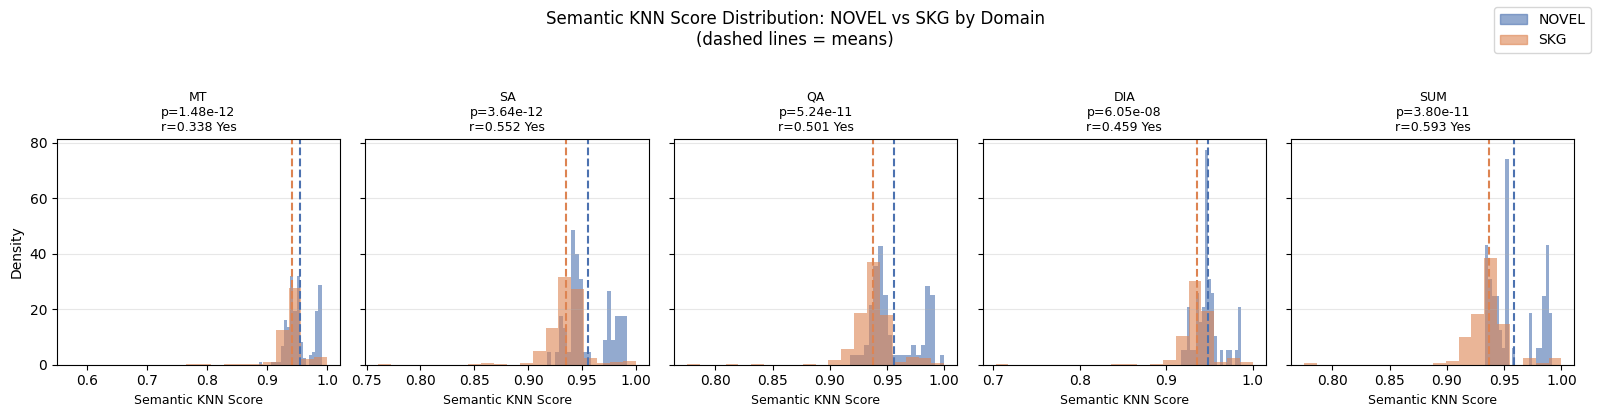

Saved semantic_validation_distributions.png


In [4]:
## 3. Visualisation — Score Distributions by Domain
fig, axes = plt.subplots(1, len(MAIN_DOMAINS), figsize=(16, 4), sharey=True)

colors = {'NOVEL': '#4C72B0', 'SKG': '#DD8452'}

for ax, domain in zip(axes, MAIN_DOMAINS):
    sub = df[df['domain'] == domain]
    for split, color in colors.items():
        vals = sub[sub['split'] == split]['semantic_knn'].dropna()
        ax.hist(vals, bins=20, alpha=0.6, color=color,
                label=split, density=True)
        ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=1.5)

    # Significance annotation
    row = results_df[results_df['domain'] == domain]
    if len(row):
        sig_text = f"p={row.iloc[0]['p_value']:.2e}\nr={row.iloc[0]['effect_r']:.3f} {row.iloc[0]['significant']}"
        ax.set_title(f'{domain}\n{sig_text}', fontsize=9)
    else:
        ax.set_title(domain)

    ax.set_xlabel('Semantic KNN Score', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Density', fontsize=10)
legend_patches = [mpatches.Patch(color=c, label=s, alpha=0.6)
                  for s, c in colors.items()]
fig.legend(handles=legend_patches, loc='upper right', fontsize=10)
fig.suptitle('Semantic KNN Score Distribution: NOVEL vs SKG by Domain\n(dashed lines = means)',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/semantic_validation_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved semantic_validation_distributions.png')

In [5]:
## 4. Classification Threshold
# Using 75th percentile of semantic_knn on the clean 2010–2021 subset
# as the novelty threshold. Papers above = Novel, below = Incremental.
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Clean subset for threshold calibration — 2010-2021 only, no fallback noise
clean = df[df['year'] <= 2021].dropna(subset=['semantic_knn'])
threshold = clean['semantic_knn'].quantile(0.75)
print(f'Threshold (75th percentile, 2010–2021): {threshold:.4f}')

# Apply threshold to full NOVEL+SKG set
eval_df = df.dropna(subset=['semantic_knn']).copy()
eval_df['predicted_novel'] = (eval_df['semantic_knn'] >= threshold).astype(int)
eval_df['true_novel']      = (eval_df['split'] == 'NOVEL').astype(int)

y_true = eval_df['true_novel']
y_pred = eval_df['predicted_novel']

prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
cm   = confusion_matrix(y_true, y_pred)

print(f'\nClassification Results (threshold={threshold:.4f}) ')
print(f'Precision : {prec:.3f}')
print(f'Recall    : {rec:.3f}')
print(f'F1 Score  : {f1:.3f}')
print(f'\nConfusion Matrix:')
print(f'               Pred Incr.  Pred Novel')
print(f'True Incr.  :  {cm[0,0]:6d}      {cm[0,1]:6d}')
print(f'True Novel  :  {cm[1,0]:6d}      {cm[1,1]:6d}')

# Save labelled output
eval_df[['paper_id','title','domain','year','split',
         'semantic_knn','predicted_novel']].to_csv(
    f'{OUT_DIR}/semantic_classification_output.csv', index=False)
print('\nSaved semantic_classification_output.csv')

Threshold (75th percentile, 2010–2021): 0.9474

Classification Results (threshold=0.9474) 
Precision : 0.330
Recall    : 0.509
F1 Score  : 0.400

Confusion Matrix:
               Pred Incr.  Pred Novel
True Incr.  :    1679         420
True Novel  :     200         207

Saved semantic_classification_output.csv


In [6]:
## Summary
print('Semantic-Primary Novelty Validation — Summary')
print()
print(f'Primary metric  : semantic_knn (SciBERT cosine dissimilarity, k=5 neighbours)')
print(f'Overall p-value : {p:.2e}  → {"Significant" if p < 0.05 else "Not significant"}')
print(f'Overall r       : {r:.3f} ({effect_label(r)} effect)')
print()
print('Per-domain significance:')
for _, row in results_df.iterrows():
    print(f'  {row["domain"]} : p={row["p_value"]:.2e}  r={row["effect_r"]:.3f}  {row["significant"]}')
print()
print(f'Classification threshold : {threshold:.4f} (75th pctile, 2010–2021)')
print(f'Precision : {prec:.3f}')
print(f'Recall    : {rec:.3f}')
print(f'F1        : {f1:.3f}')
print()
print('Outputs saved:')
print('  semantic_validation_by_domain.csv')
print('  semantic_validation_distributions.png')
print('  semantic_classification_output.csv')

Semantic-Primary Novelty Validation — Summary

Primary metric  : semantic_knn (SciBERT cosine dissimilarity, k=5 neighbours)
Overall p-value : 5.39e-45  → Significant
Overall r       : 0.439 (Medium effect)

Per-domain significance:
  MT : p=1.48e-12  r=0.338  Yes
  SA : p=3.64e-12  r=0.552  Yes
  QA : p=5.24e-11  r=0.501  Yes
  DIA : p=6.05e-08  r=0.459  Yes
  SUM : p=3.80e-11  r=0.593  Yes

Classification threshold : 0.9474 (75th pctile, 2010–2021)
Precision : 0.330
Recall    : 0.509
F1        : 0.400

Outputs saved:
  semantic_validation_by_domain.csv
  semantic_validation_distributions.png
  semantic_classification_output.csv
